In [1]:
library(tidyverse)
library(forecast)

#-----------------
options(
    repr.plot.width = 14,
    repr.plot.height = 9
)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.2.1     v readr     2.2.0
v forcats   1.0.1     v stringr   1.6.0
v ggplot2   4.0.3     v tibble    3.3.1
v lubridate 1.9.5     v tidyr     1.3.2
v purrr     1.2.2     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# Load and pre-process data from [Danmarks Statistik](https://www.dst.dk/da/)

In [2]:
data_full <- read.csv("data_danmarks_statistik/danish_milk_production.csv", na = '..')

In [3]:
glimpse(data_full)

Rows: 372
Columns: 16
$ date                                                                                       <chr> ~
$ Milk.ex.farm..total..m.kg.                                                                 <dbl> ~
$ Delivered.milk.to.dairies..m.kg.                                                           <dbl> ~
$ Delivered.organic.milk.to.dairies..m.kg.                                                   <dbl> ~
$ Avarage.fat.content.of.delivered.milk.to.the.dairies..percent.                             <dbl> ~
$ Avarage.protein.content.of.delivered.milk.to.dairies..percent.                             <dbl> ~
$ Milk.ex.farm..total..DK.ore.per.kg.                                                        <dbl> ~
$ Milk.ex.farm.with.4.2..fat.content.and.3.4.protein.content..DK.ore.pr..kg.                 <dbl> ~
$ Milk.ex.farm..total..DKK.Mio.                                                              <dbl> ~
$ Production.of.butter..m.kg.                                        

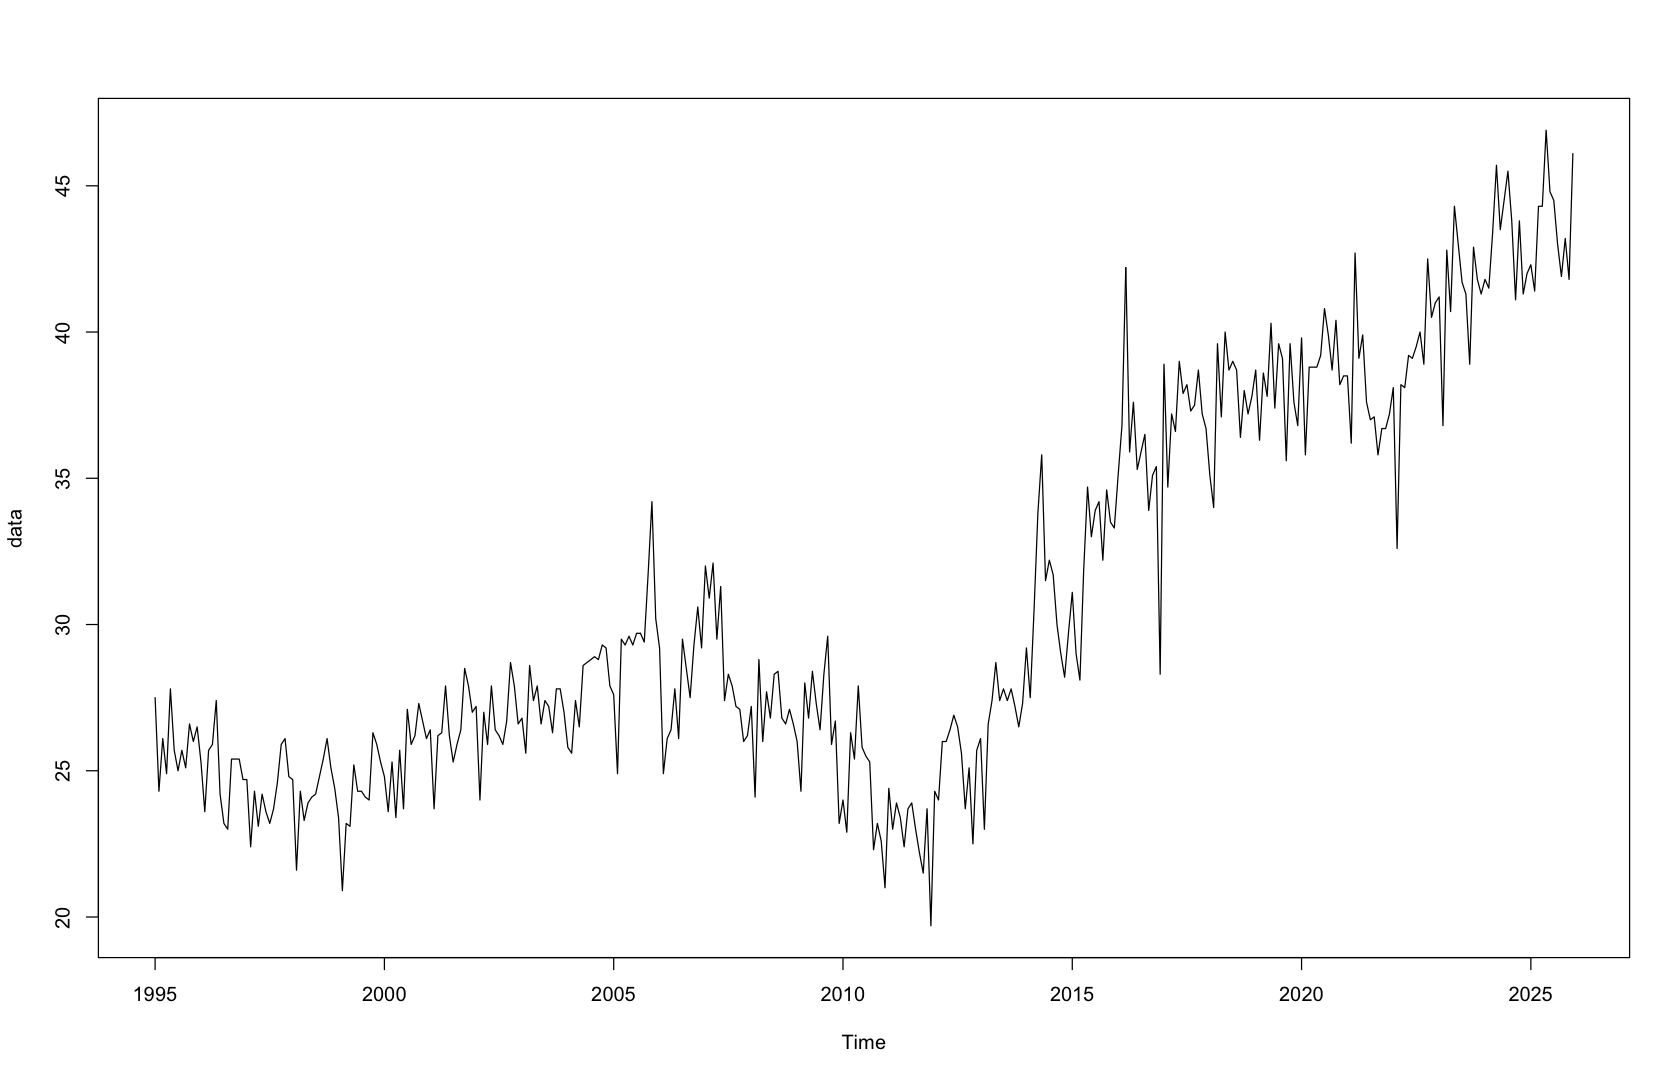

In [4]:
data <- ts(data_full$Production.of.cheese..total..m.kg.,
                start = c(1995, 1),
                frequency = 12,
                )

#--------------------------------------------------------
# Crop the data if needed
# data <- window(data, start = 2007)

# Log-transform if variance changes with time
# data <- log(data)

plot(data)

## Split into training and testing data (for forecasting), 95% and 5%, respectively

In [5]:
n <- length(data)
n_train <- floor(0.95 * n) # 95% of the data are training data
#---------------
data_train <- window(data, end = time(data)[n_train])
data_test  <- window(data, start = time(data)[n_train + 1])

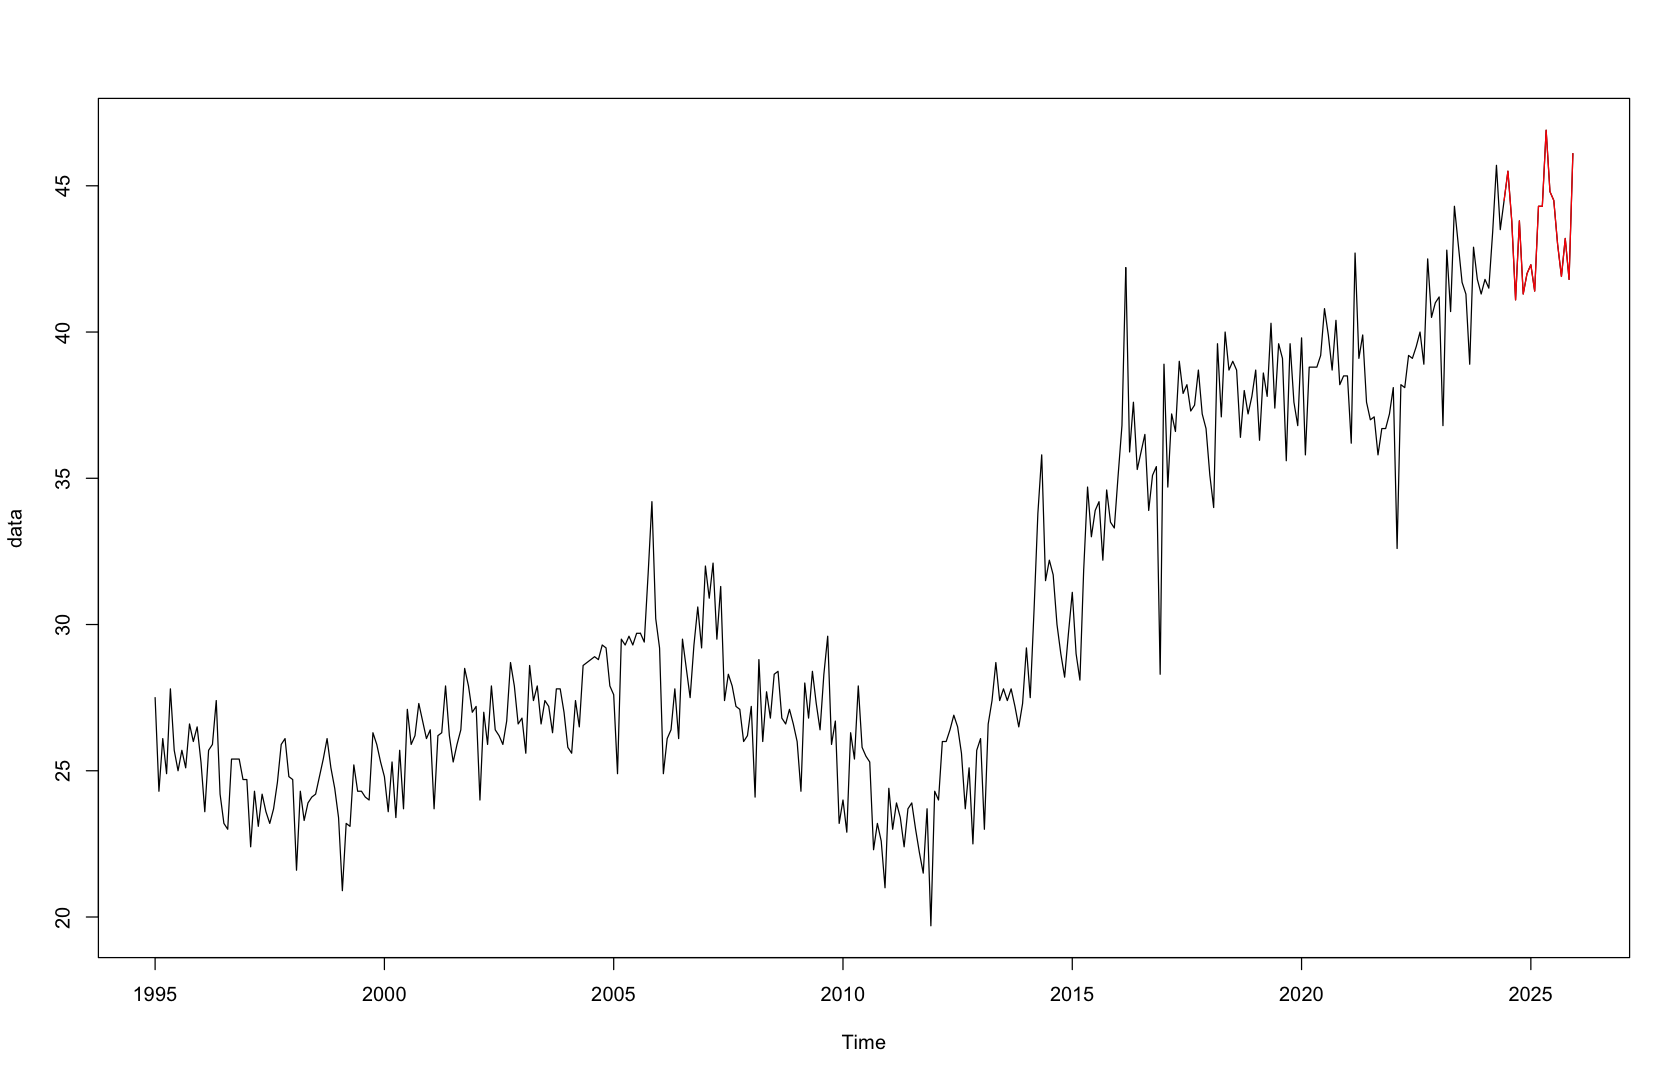

In [6]:
plot(data)
lines(data_test, col = 'red')

***

## Check ACF and PACF

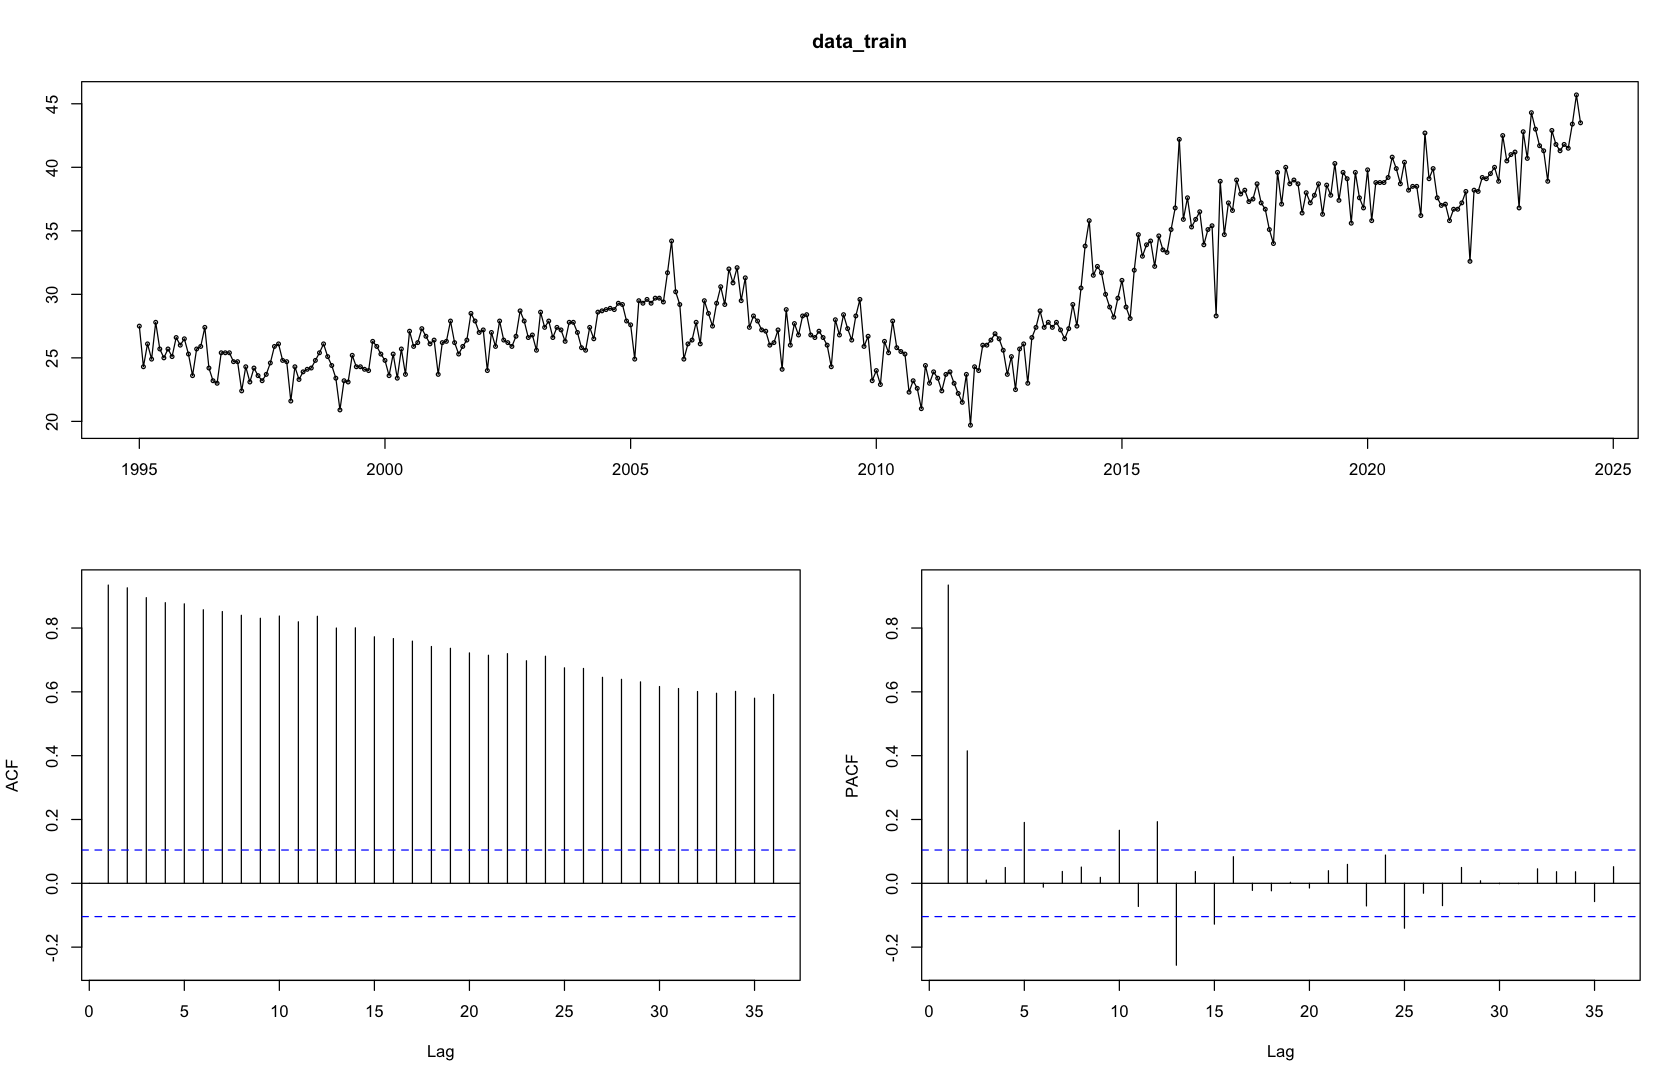

In [7]:
tsdisplay(data_train)

## Test for stationarity

In [8]:
library(tseries)

adf.test(data_train)

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 




	Augmented Dickey-Fuller Test

data:  data_train
Dickey-Fuller = -1.8147, Lag order = 7, p-value = 0.655
alternative hypothesis: stationary


## Test for seasonality

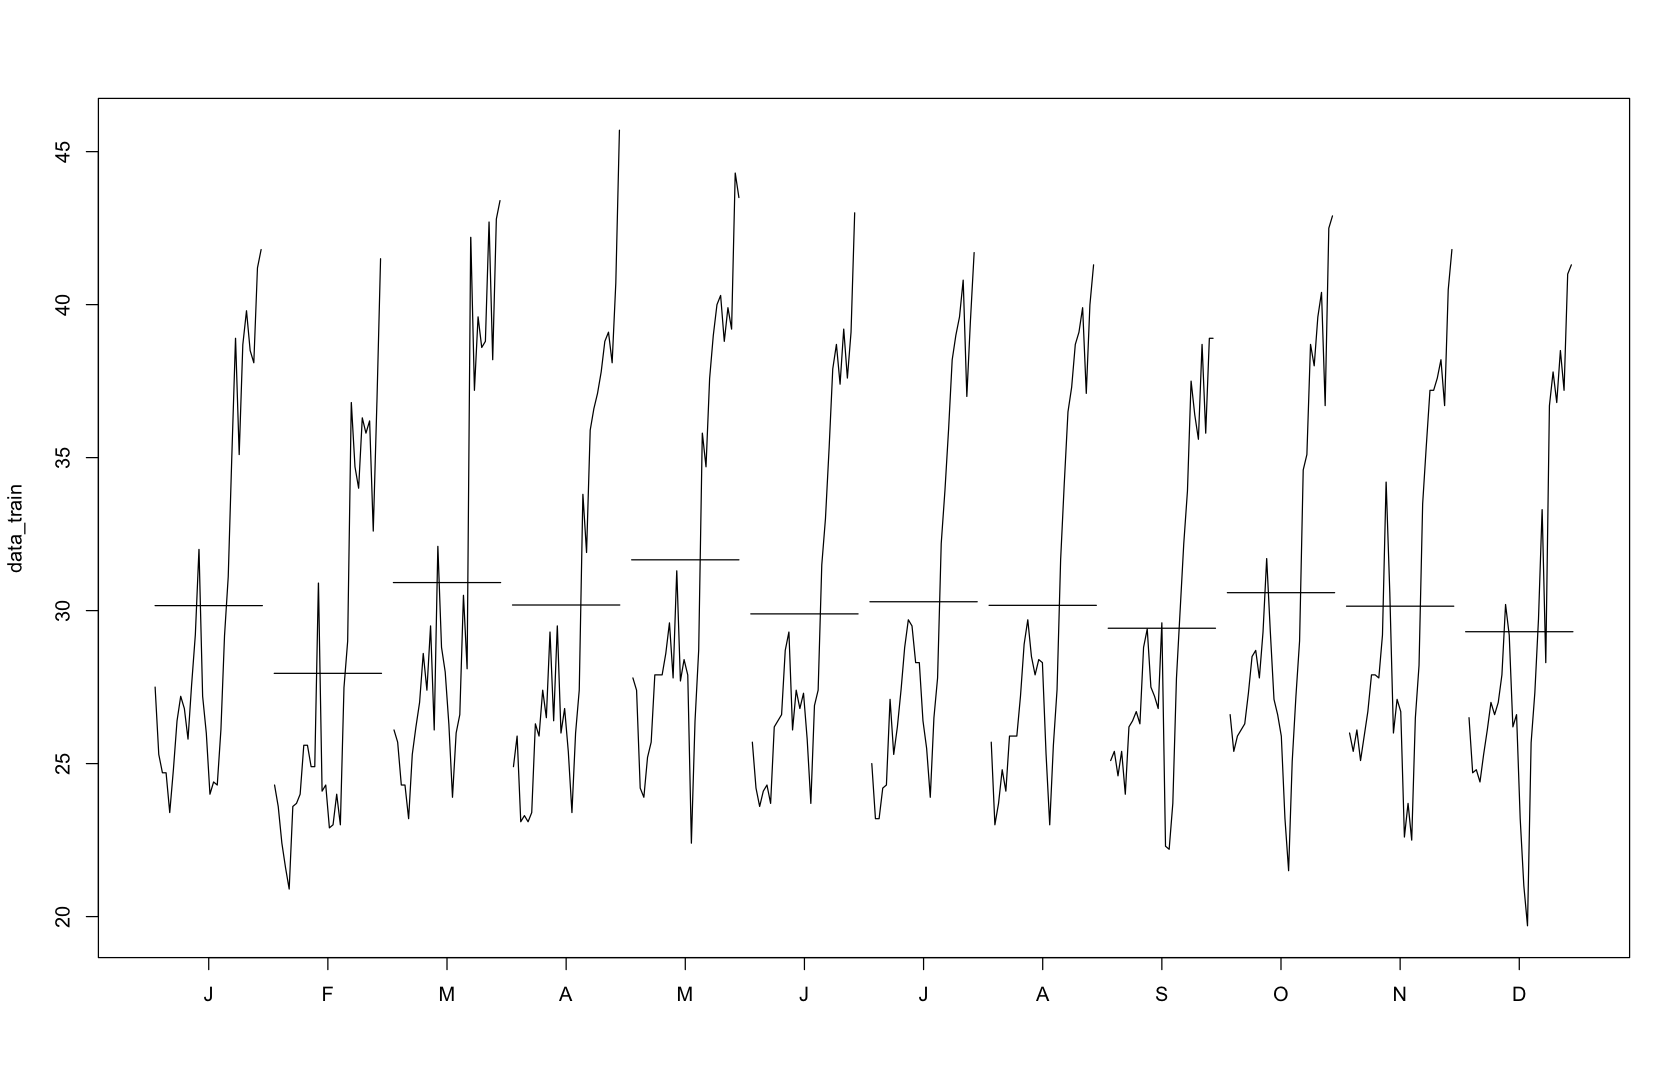

In [9]:
monthplot(data_train)

## Time series is non-stationary with a seasonal trend

***

## Seasonal-Trend decomposition using LOESS (STL)

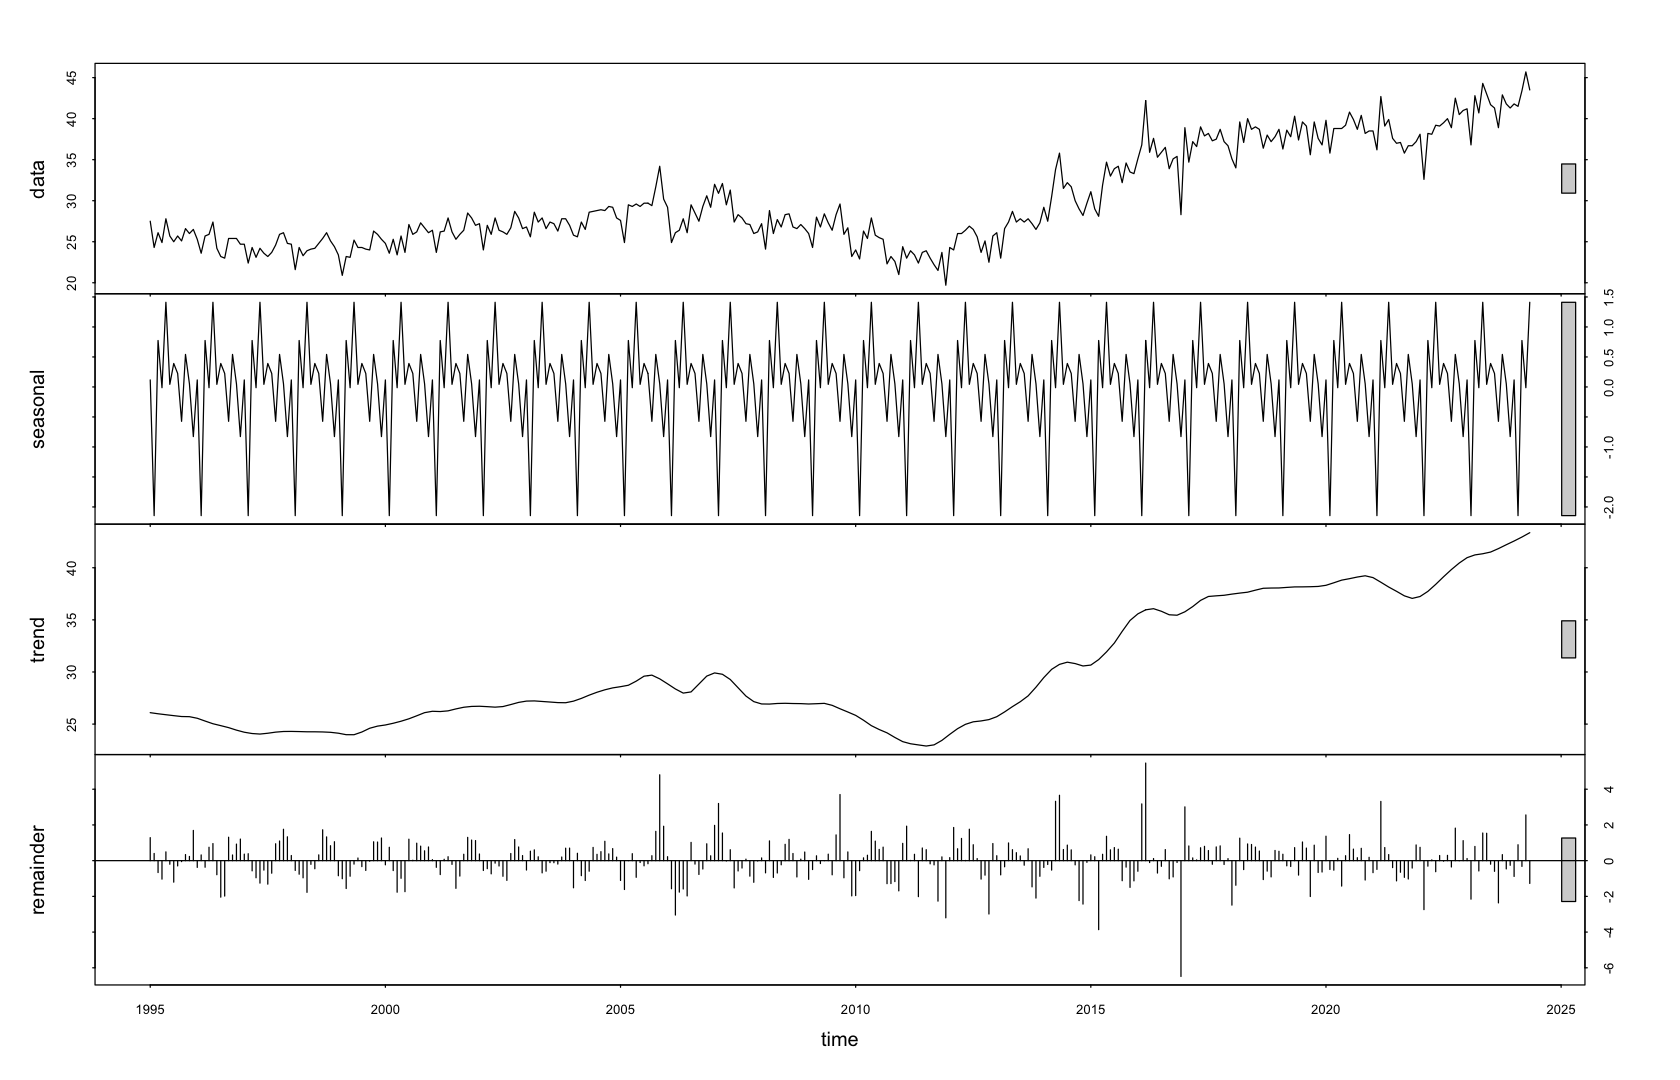

In [10]:
decomposed = stl(data_train, s.window = "periodic")

plot(decomposed)

In [11]:
forecast_stl_arima = stlf(
                        data_train, 
                        method = "arima",
                        h = n - n_train,
                        level = c(80, 95),
                        )


	Ljung-Box test

data:  Residuals from STL +  ARIMA(0,1,1)
Q* = 56.637, df = 23, p-value = 0.0001152

Model df: 1.   Total lags used: 24



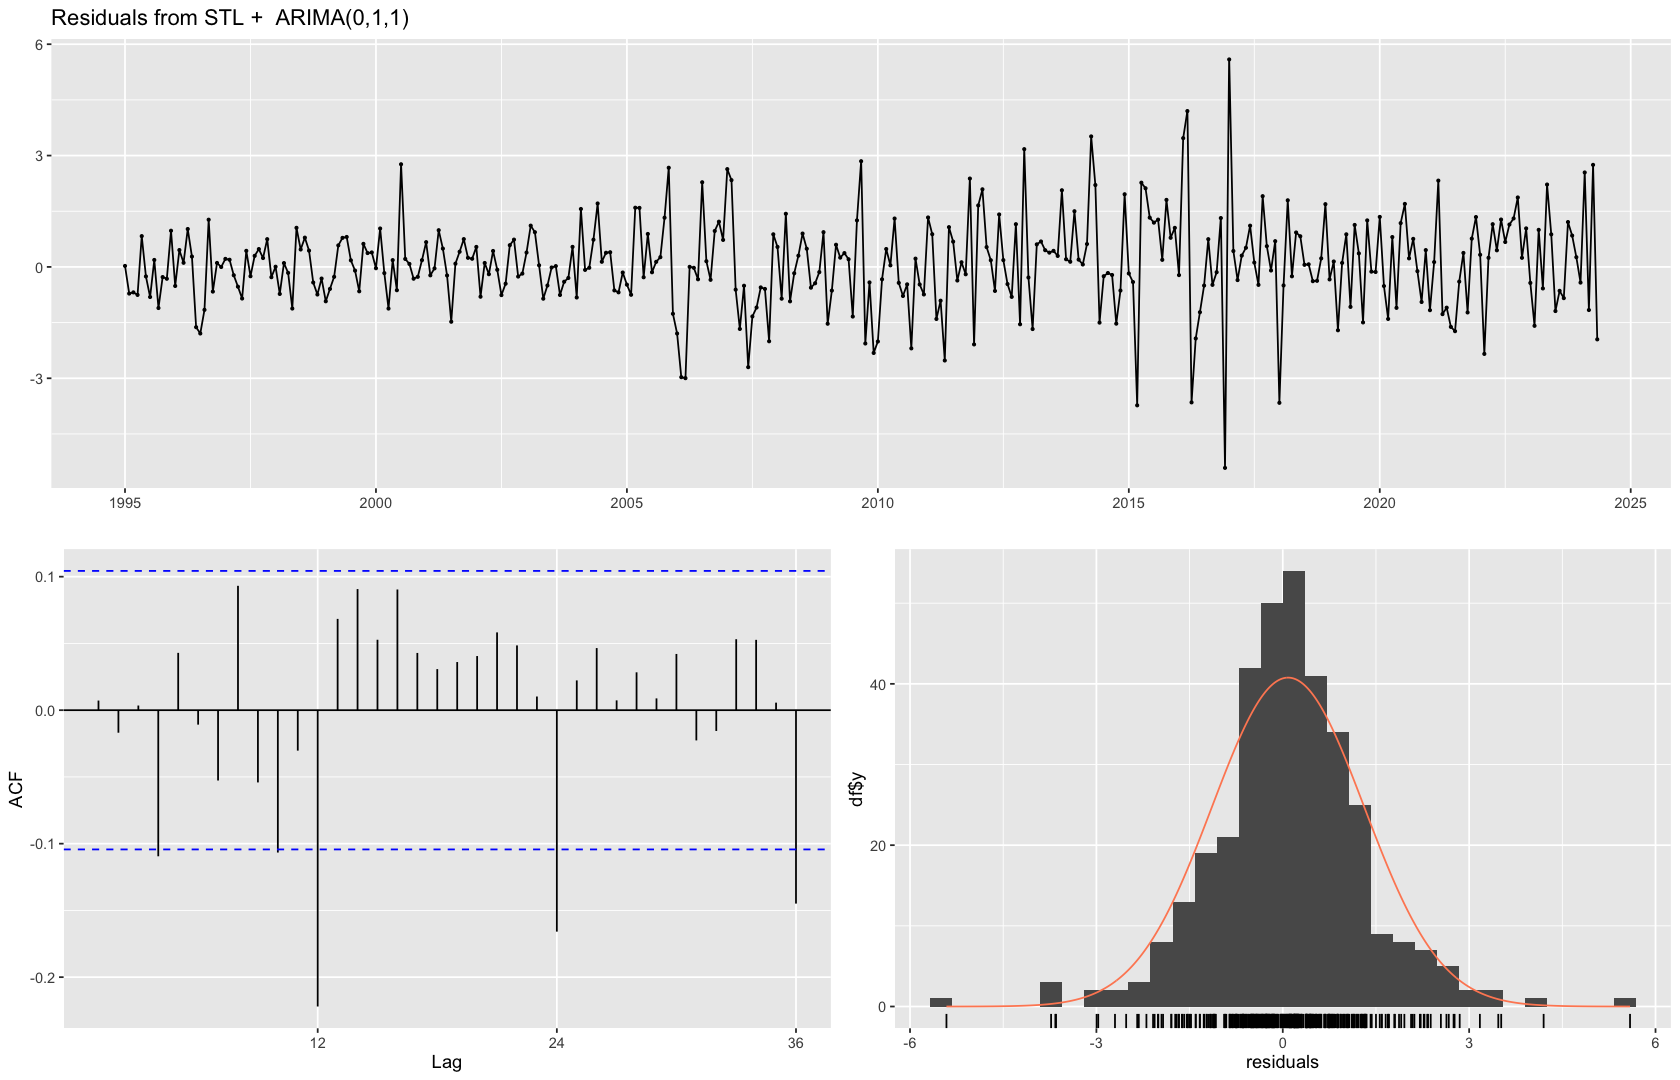

In [12]:
checkresiduals(forecast_stl_arima)

### compare raw data (black) vs. fitted model (red)

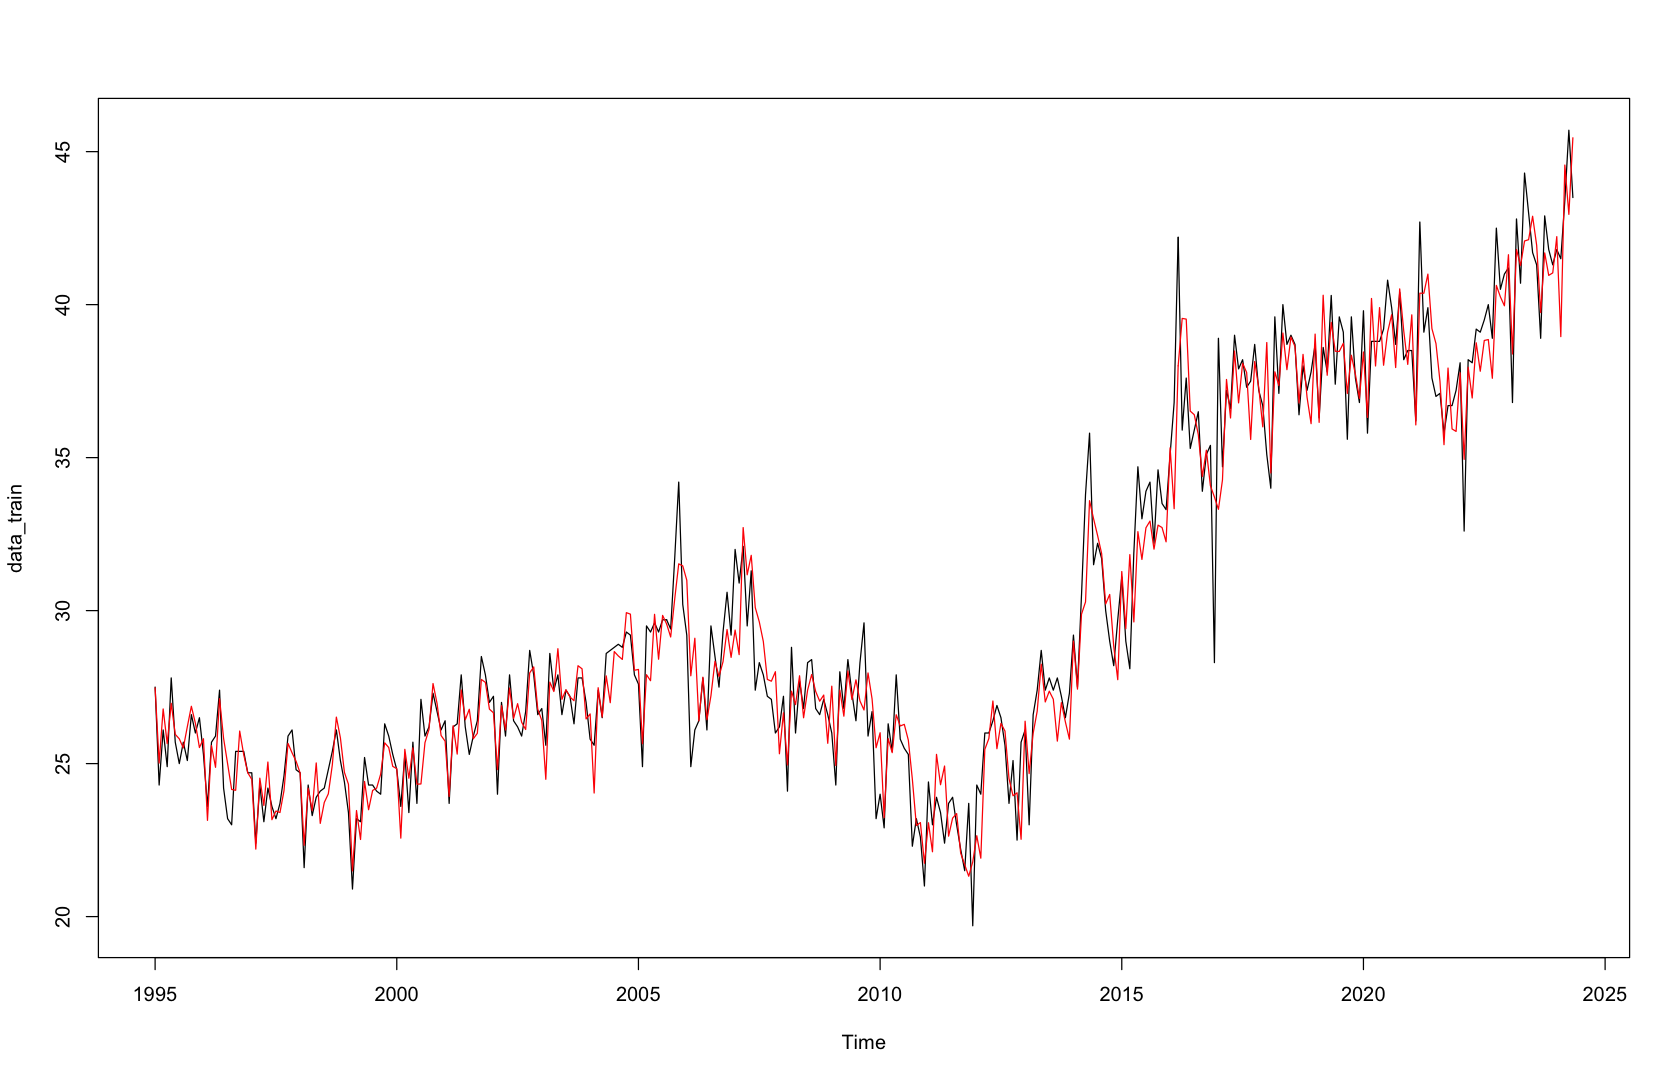

In [13]:
plot(data_train, type = "l")
lines(forecast_stl_arima$fitted, col = "red")

### forecast fitted STL-ARIMA model

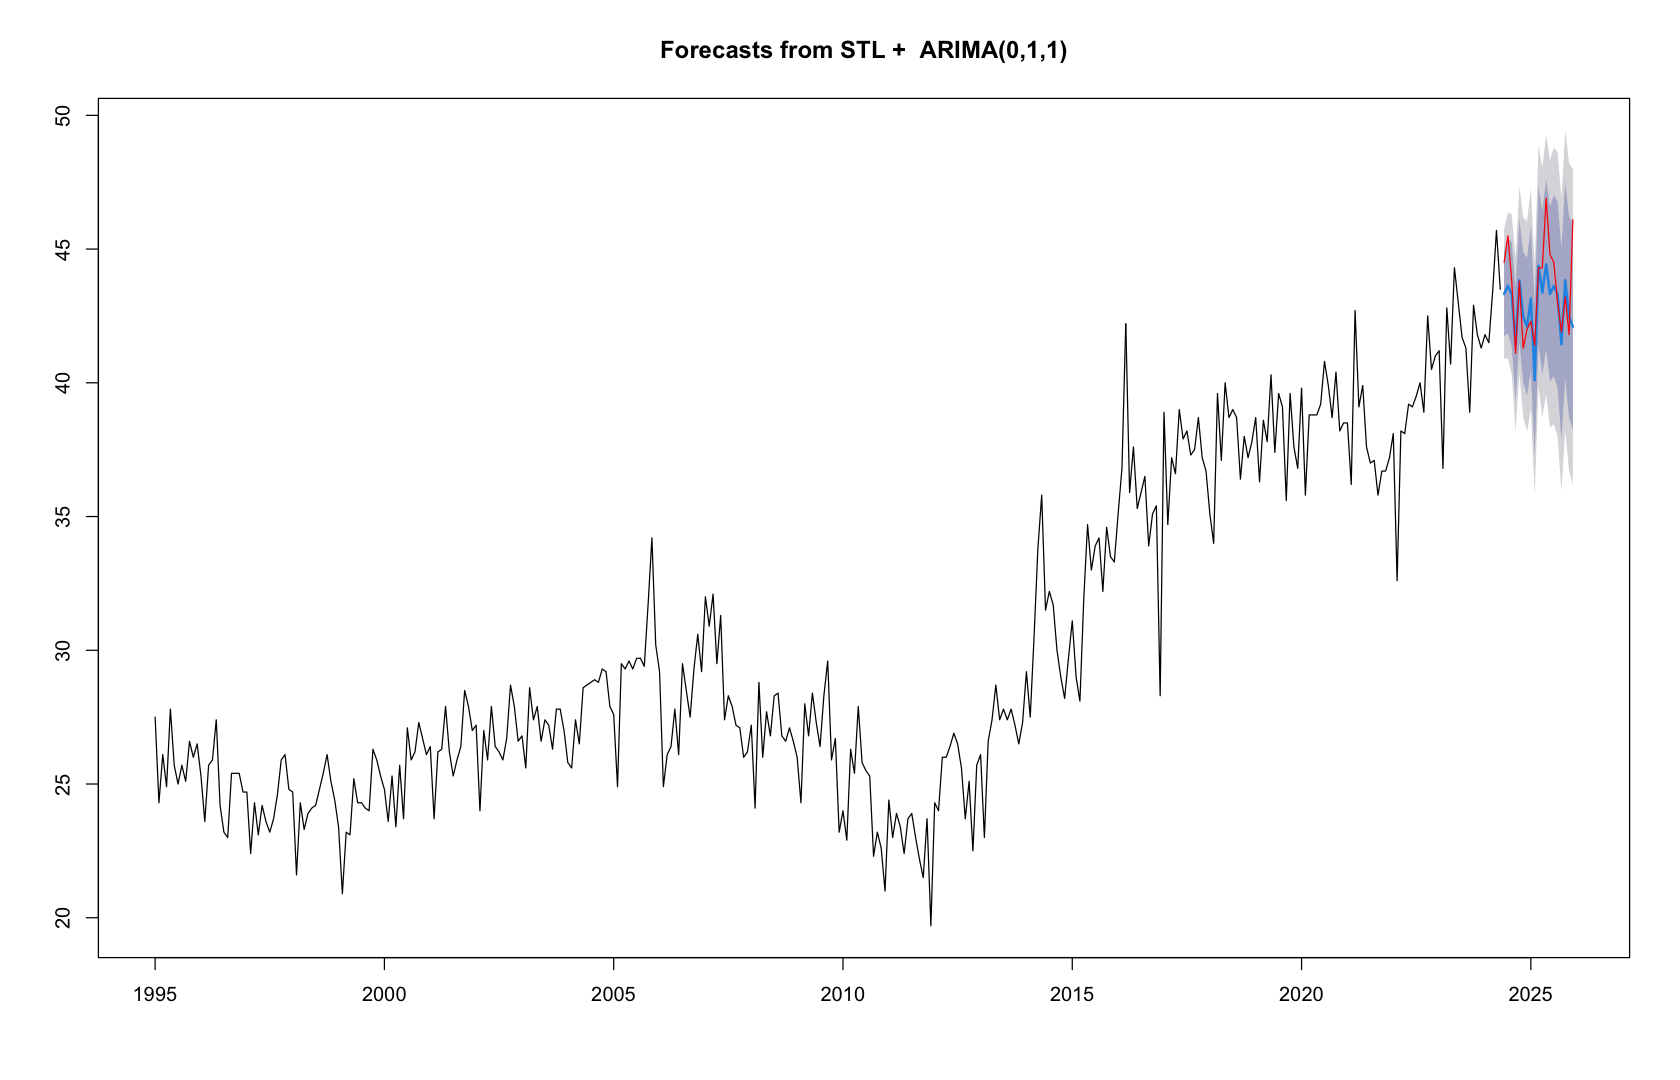

In [14]:
plot(forecast_stl_arima)
lines(data_test, col = 'red')

***

## ETS-model

In [15]:
ets_model <- ets(data_train)

ets_model

ETS(M,Ad,M) 

Call:
ets(y = data_train)

  Smoothing parameters:
    alpha = 0.5734 
    beta  = 1e-04 
    gamma = 1e-04 
    phi   = 0.9786 

  Initial states:
    l = 26.3553 
    b = -0.0359 
    s = 0.9744 1.0005 1.0171 0.9832 1.0068 1.0139
           1.0002 1.0465 0.9982 1.0236 0.9288 1.0068

  sigma:  0.0485

     AIC     AICc      BIC 
2340.742 2342.790 2410.338 


	Ljung-Box test

data:  Residuals from ETS(M,Ad,M)
Q* = 51.108, df = 24, p-value = 0.001021

Model df: 0.   Total lags used: 24



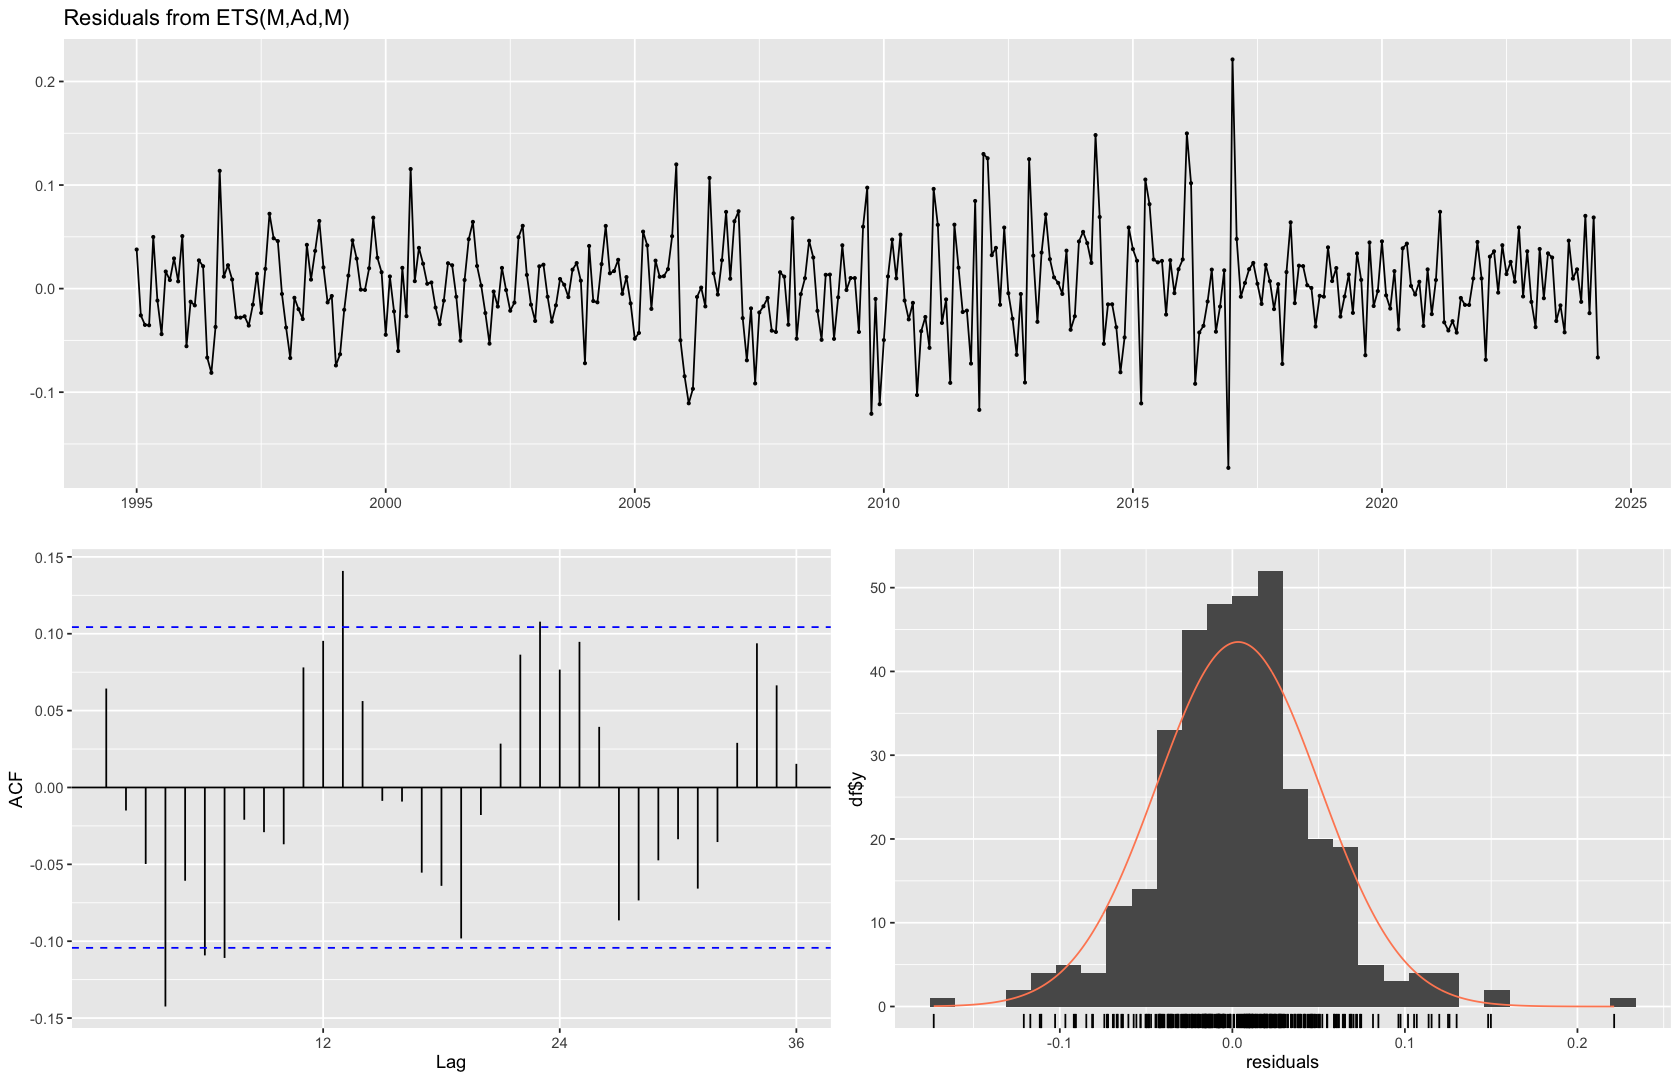

In [16]:
checkresiduals(ets_model)

### compare raw data (black) vs. fitted model (red)

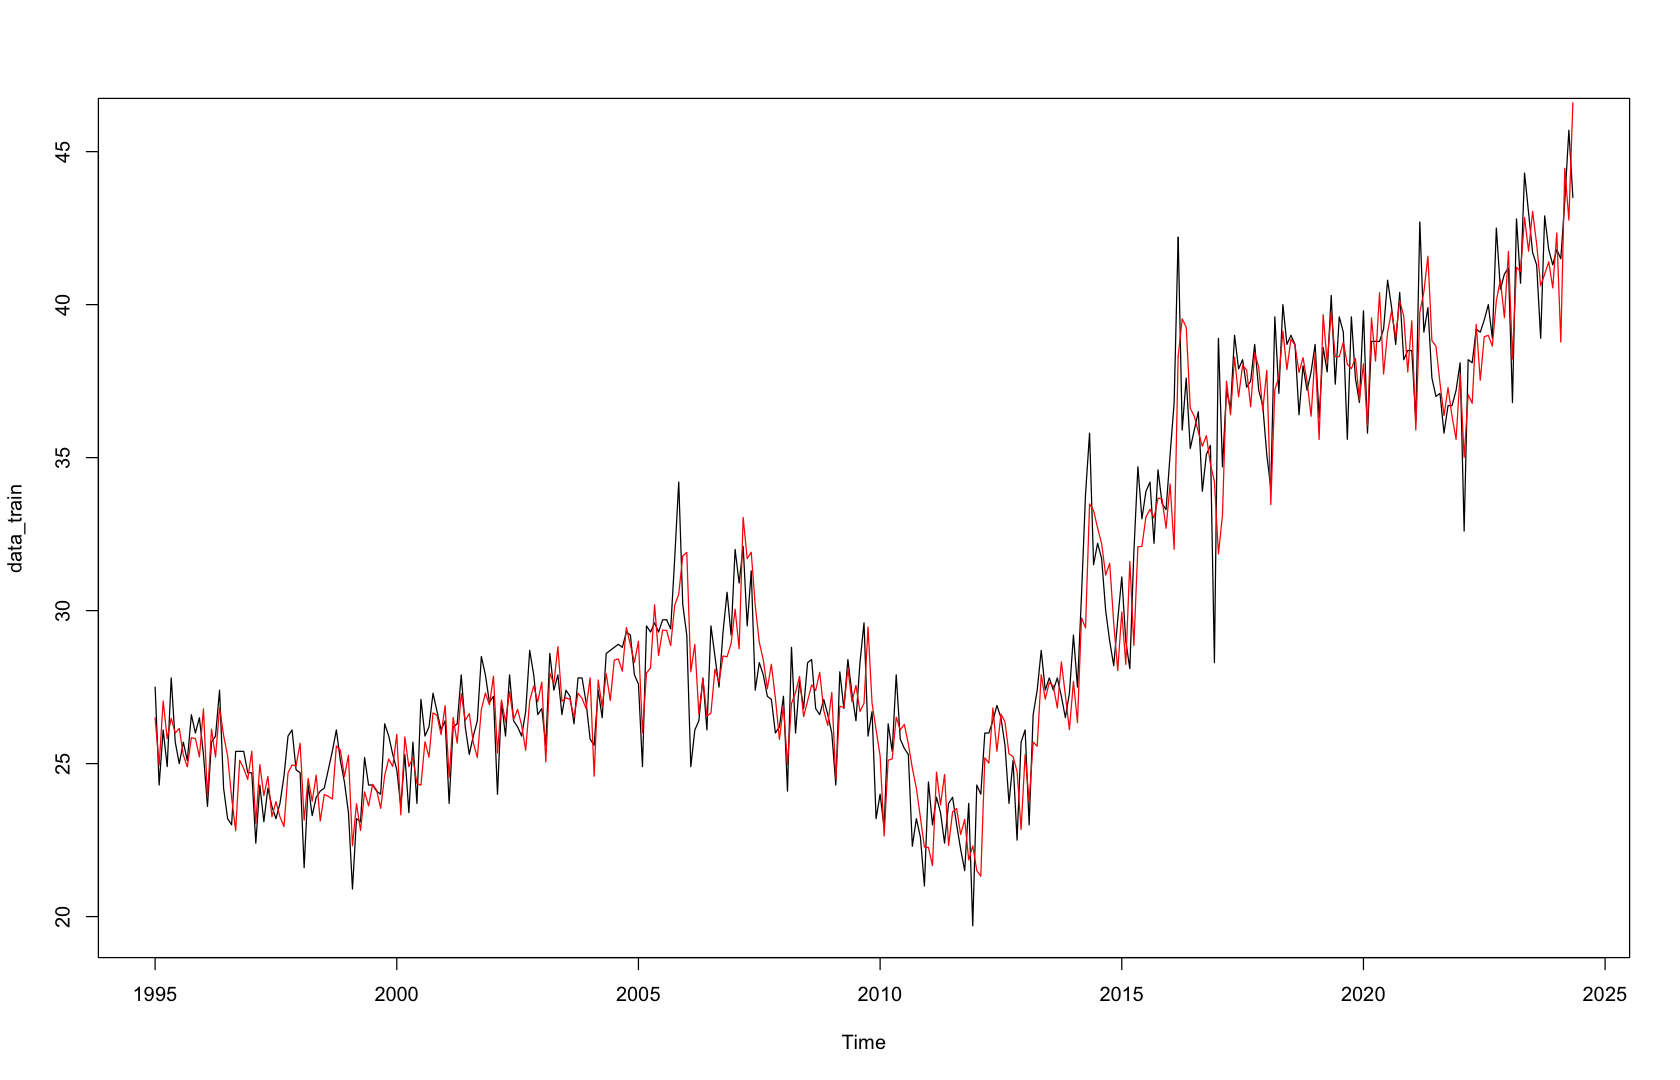

In [17]:
plot(data_train, type = "l")
lines(ets_model$fitted, col = "red")

### forecast fitted ETS model

In [18]:
forecast_ets <- forecast(ets_model, h = n - n_train) 

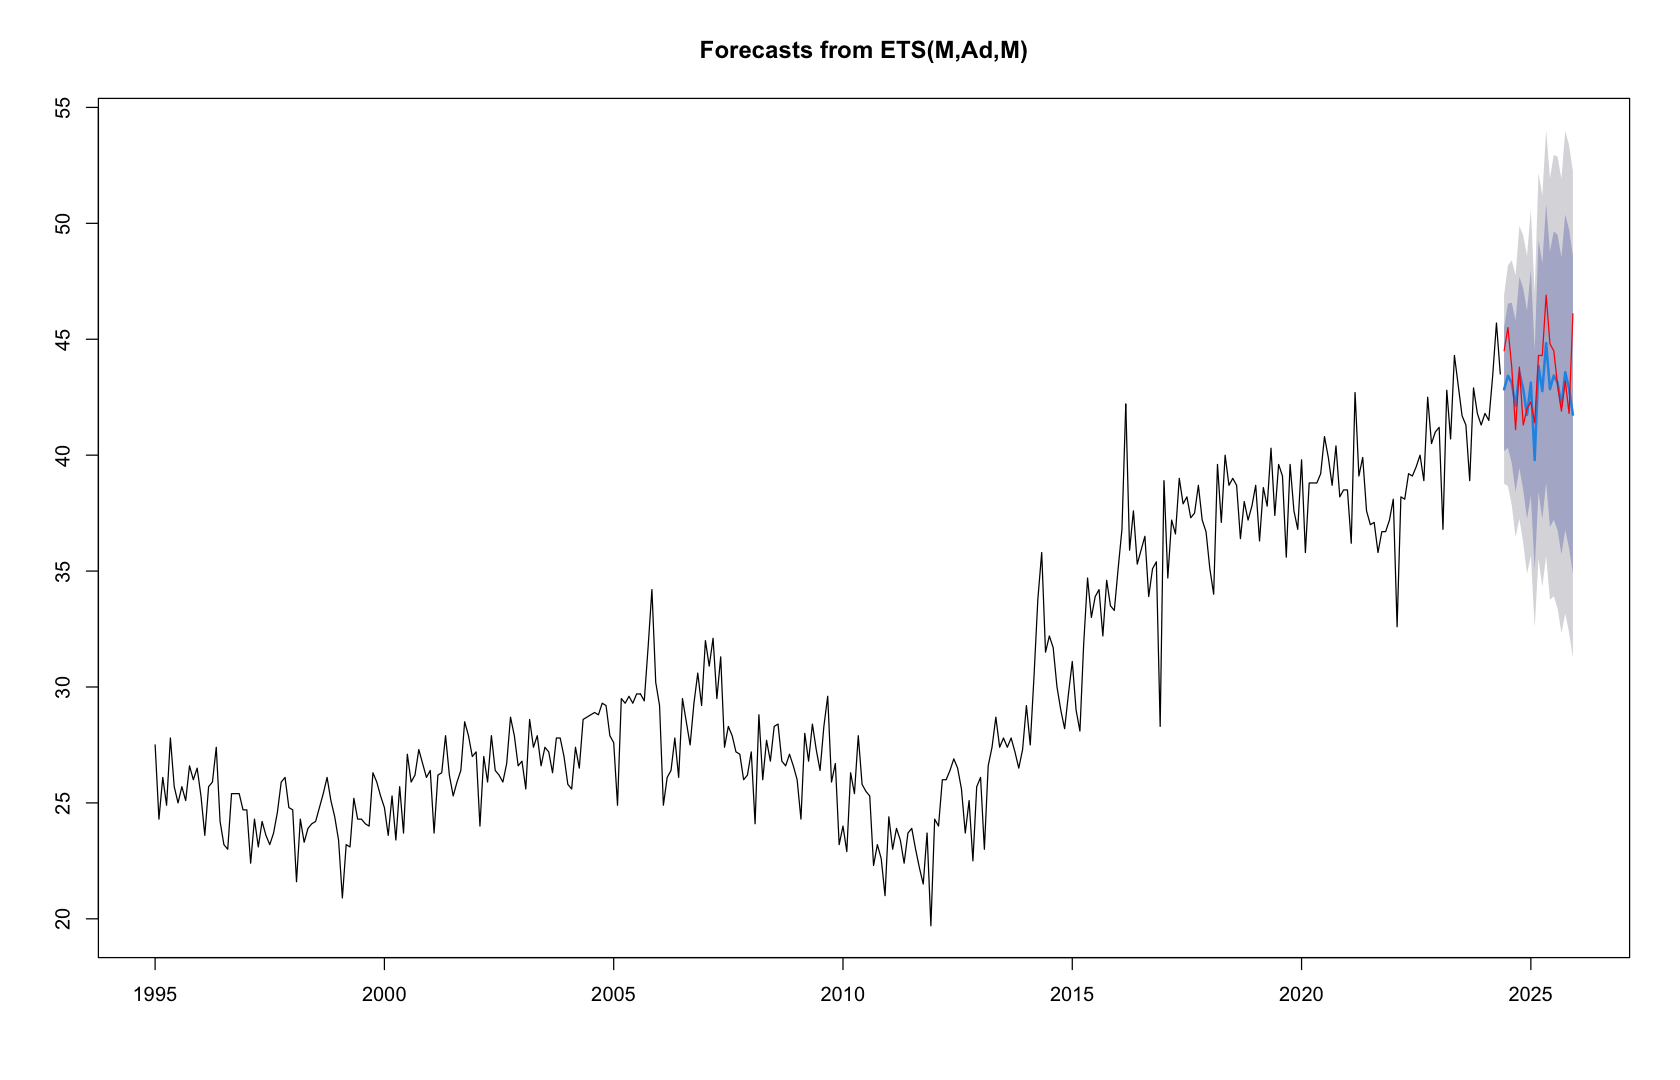

In [19]:
plot(forecast_ets)
lines(data_test, col = 'red')

## Compare accuracies of STL-ARIMA vs. ETS models

In [20]:
accuracy(forecast_stl_arima, data_test)
accuracy(forecast_ets, data_test)

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,0.08534464,1.227220,0.8919145,0.1216578,2.985884,0.4847670,0.007199196,NA
Test set,0.57508915,1.378855,1.0113452,1.2426974,2.280087,0.5496792,0.089323798,0.6943943


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,0.0890338,1.398633,1.045119,0.1130458,3.537912,0.5680357,0.03214997,NA
Test set,0.6716327,1.563608,1.217480,1.4499781,2.758328,0.6617160,0.08182822,0.7772916


***

# Summary:
- STL-ARIMA model outperforms the ETS model by essentially every relevant test-set measure. 

***